**CESAR - School**<br>
**Especialização: Engenharia e Análise de Dados** - **Turma:** 2025.2<br>
**RNA e Deep Learning**<br>
**Aula 2 - Exercício 4**

**Docente:** Vitor Casadei<br>
**Discente:** Caio Augustus Lima de Abreu Monteiro<br>


# Regressão Linear com PyTorch

## Objetivo

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se
- o cálculo do gradiente automático do PyTorch, porém
- a função de perda e
- atualização dos parâmetros é feita de forma explícita.
- A rede é criada com uma camada nn.Linear()

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinear_Otimizacao.png)

## Importação dos pacotes

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
from sklearn.datasets import load_iris

import torch
from torch import nn, optim
from torch.autograd import Variable

torch.manual_seed(1234)

## Leitura dos dados

In [2]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [3]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [4]:
print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train[:5]:
 [[1.        ]
 [0.71428573]
 [0.952381  ]
 [0.28571424]
 [0.7619048 ]]
y_train[:5]:
 [[0.80952376]
 [0.71428573]
 [0.90476197]
 [0.4761905 ]
 [0.7619048 ]]


In [5]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [6]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428573],
       [1.        , 0.95238101],
       [1.        , 0.28571424],
       [1.        , 0.76190478],
       [1.        , 0.38095227],
       [1.        , 0.66666675],
       [1.        , 0.        ],
       [1.        , 0.80952376],
       [1.        , 0.14285702],
       [1.        , 0.047619  ],
       [1.        , 0.47619051],
       [1.        , 0.52380949],
       [1.        , 0.57142848],
       [1.        , 0.33333325],
       [1.        , 0.85714275],
       [1.        , 0.33333325],
       [1.        , 0.42857149],
       [1.        , 0.61904752],
       [1.        , 0.33333325],
       [1.        , 0.47619051],
       [1.        , 0.57142848],
       [1.        , 0.66666675],
       [1.        , 0.57142848],
       [1.        , 0.71428573],
       [1.        , 0.80952376],
       [1.        , 0.90476197],
       [1.        , 0.85714275],
       [1.        , 0.52380949],
       [1.        , 0.38095227],
       [1.

In [7]:
print('x_train_bias.shape:',x_train_bias.shape, x_train_bias.dtype)

x_train_bias.shape: (50, 2) float64


In [8]:
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)
print(y_train)

tensor([[0.8095],
        [0.7143],
        [0.9048],
        [0.4762],
        [0.7619],
        [0.7143],
        [0.8095],
        [0.1429],
        [0.7619],
        [0.4286],
        [0.2381],
        [0.5714],
        [0.4762],
        [0.8095],
        [0.2857],
        [0.6667],
        [0.7143],
        [0.5238],
        [0.7143],
        [0.4286],
        [0.8571],
        [0.4762],
        [0.9048],
        [0.8095],
        [0.6190],
        [0.6667],
        [0.8571],
        [0.9524],
        [0.7143],
        [0.2381],
        [0.3810],
        [0.3333],
        [0.4286],
        [1.0000],
        [0.7143],
        [0.7143],
        [0.8095],
        [0.6667],
        [0.5238],
        [0.4762],
        [0.6667],
        [0.7619],
        [0.4762],
        [0.1429],
        [0.5714],
        [0.5714],
        [0.5714],
        [0.6190],
        [0.0000],
        [0.5238]])


## Model

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinearNeuronio.png)

In [9]:
#Inicialização usando toch.nn.Linear

model = torch.nn.Linear(in_features=2, out_features=1, bias=False)

### Verificando a inicialização dos parâmetros

In [10]:
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform(model.weight.data, -0.1, 0.1)
model.weight

/tmp/ipykernel_561/2197199425.py:2: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


Parameter containing:
tensor([[-0.0480, -0.0267]], requires_grad=True)

### Testando o predict da rede

In [11]:
xx = torch.ones((5,2))
xx

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [12]:
model(Variable(xx))

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

## Treinamento

### Modificação do laço de treinamento (Atividade 3)

A coleta da evolução dos parâmetros exige uma alteração interna ao laço de treinamento. Para isso, foram criadas as listas `w0_list` e `w1_list`, e a cada época registra-se o valor corrente de cada parâmetro por meio de `model.weight.data[0, 0].item()` e `model.weight.data[0, 1].item()`.

Dois aspectos de implementação merecem destaque:

- **Uso de `.item()`**: o método extrai o valor escalar como um `float` nativo do Python. Sem ele, seriam armazenadas referências ao tensor `model.weight.data`, que é sobrescrito a cada iteração; como consequência, todas as posições das listas convergiriam para o mesmo valor final. O `.item()` garante que o valor de cada época seja preservado de forma independente.
- **Momento do registro**: os pesos são armazenados antes da etapa de atualização. Dessa forma, `w0_list[0]` corresponde ao ponto de inicialização, e a trajetória resultante representa fielmente o percurso percorrido pelo gradiente descendente desde o seu início.

In [13]:
num_epochs = 100
learning_rate = 0.5

# Atividade 3: listas para guardar a evolução dos parâmetros
w0_list = []
w1_list = []

for epoch in range(num_epochs):
    #inputs = Variable(x_train_bias)
    #target = Variable(y_train)
    inputs = x_train_bias
    target = y_train

    # forward - predict
    y_pred = model(inputs)

    #loss cálculo da função de perda
    loss = torch.mean((y_pred - target)**2)

    # Atividade 3: guarda os valores atuais dos parâmetros (antes do passo)
    w0_list.append(model.weight.data[0, 0].item())
    w1_list.append(model.weight.data[0, 1].item())

    # backward propagation - cálculo gradient
    loss.backward()

    # gradiente descendente
    model.weight.data = model.weight.data - learning_rate * model.weight.grad.data

    # zeragem parâmetros próximo cálculo do gradiente
    model.weight.grad.data.zero_()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.data))

Epoch[20/100], loss: 0.022983
Epoch[40/100], loss: 0.021432
Epoch[60/100], loss: 0.021207
Epoch[80/100], loss: 0.021175
Epoch[100/100], loss: 0.021170


## Avaliação

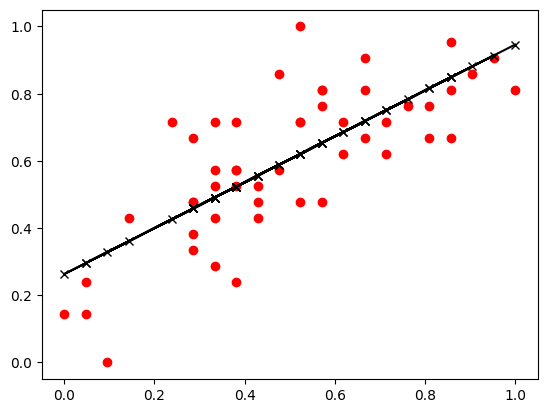

In [14]:
y_pred = model(Variable(x_train_bias))
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

### Acessando os parâmetros

In [15]:
w_dic = model.state_dict()
w_dic

OrderedDict([('weight', tensor([[0.2631, 0.6830]]))])

### Parâmetros ótimos, solução analítica

In [16]:
x_bias = x_train_bias
y = y_train
x_bias_t = torch.t(x_bias)
w_opt = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)
print(torch.t(w_opt))

tensor([[0.2613, 0.6865]])


# Exercícios

- 1) Por que no final da varredura do laço de treinamento, a perda é impressa utilizando
   `loss.data`? Por que precisa do `data`?
   

**Resposta:**

A perda é impressa por meio de `loss.data` porque a variável `loss` não armazena um valor numérico simples, mas um tensor que mantém associado todo o grafo computacional do autograd. Ao executar `loss = torch.mean((y_pred - target)**2)`, o PyTorch registra que esse tensor foi derivado de `y_pred` e, por consequência, de `model.weight`. Esse encadeamento de operações é precisamente o que viabiliza o cálculo automático dos gradientes em `loss.backward()`. A presença do grafo pode ser verificada ao inspecionar o tensor, que exibe o atributo `grad_fn=<MeanBackward0>`.

O atributo `.data` fornece acesso somente ao valor numérico do tensor, desvinculando-o do grafo computacional. Esse desacoplamento é relevante por duas razões:

1. **Gerenciamento de memória**: o armazenamento de referências ao tensor completo, com o grafo associado, manteria vivos todos os tensores intermediários ao longo das épocas, resultando em consumo crescente e desnecessário de memória.
2. **Isolamento do autograd**: operações realizadas sobre `.data` não são rastreadas pelo mecanismo de diferenciação automática, evitando interferências no cálculo do gradiente das iterações subsequentes.

Em versões atuais do PyTorch, recomenda-se o uso de `loss.item()` — que retorna diretamente um valor escalar do tipo `float`, apropriado para tensores de dimensão zero — ou o emprego do contexto `with torch.no_grad():`. O atributo `.data` representa uma abordagem de mais baixo nível, anterior a essas alternativas, e ainda funcional, embora ignore de forma implícita o rastreamento de gradientes.

Em síntese, o `.data` (ou, preferencialmente, o `.item()`) é necessário porque, sem ele, a operação de impressão atuaria sobre um nó de um grafo de derivadas, e não sobre o valor escalar da perda.

- 2) Calcule e imprima o valor da perda (MSE) fazendo o predict da rede com os pesos já
   treinados.

**Resposta:**

Realiza-se a predição (*forward*) da rede já treinada sobre o conjunto completo de dados e calcula-se o erro quadrático médio (MSE). A operação é envolvida pelo contexto `torch.no_grad()`, uma vez que a etapa de avaliação não requer a construção do grafo de gradientes, o que reduz o consumo de memória e explicita que não há treinamento nesta etapa.

In [17]:
# Atividade 2: MSE com os pesos já treinados
with torch.no_grad():
    y_pred_treinado = model(x_train_bias)
    mse_treinado = torch.mean((y_pred_treinado - y_train) ** 2)

print('MSE com os pesos treinados: {:.6f}'.format(mse_treinado.item()))

MSE com os pesos treinados: 0.021170


- 3) Crie duas listas `w0_list` e `w1_list` para guardar a evolução dos valores dos
   parâmetros durante o laço de treinamento.
   Modifique o exemplo do gráfico tipo **scatter plot** para visualizar a variação
   dos parâmetros do modelo duas dimensões.
   Marque neste gráfico o valor ótimo do parâmetro dado pela solução
   analítica.

## Ploting vectors

### Técnica de referência: gráfico de dispersão com vetores

O enunciado fornece um exemplo que ilustra o traçado de setas entre pontos consecutivos. O trecho é reproduzido a seguir apenas como referência, sem execução, a fim de preservar as listas `w0_list` e `w1_list` efetivamente coletadas durante o treinamento:

```python
# Exemplo (apenas ilustrativo)
w0_list = [0.1, 0.15, 0.2, 0.3]
w1_list = [0.1, 0.2, 0.18, 0.3]
plt.scatter(w0_list, w1_list)
w0_old = None
for (w0, w1) in zip(w0_list, w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01, head_width=0.01, shape='full',
                  length_includes_head=True)
    w0_old, w1_old = w0, w1
```

A solução apresentada na sequência aplica essa mesma técnica de vetores sobre as listas reais preenchidas durante o treinamento, acrescentando a codificação por cor ao longo das épocas e o marcador correspondente ao valor ótimo.

### Atividade 3 — Visualização da trajetória dos parâmetros

As listas `w0_list` e `w1_list` foram preenchidas ao longo do treinamento. O exemplo de gráfico de dispersão com vetores é adaptado para representar o percurso do par $(w_0, w_1)$ ao longo das 100 épocas, sendo o valor ótimo — obtido pela solução analítica — assinalado por um marcador em formato de estrela.

Os pontos são codificados por cor de acordo com a época (tons escuros indicam o início e tons claros indicam o final), o que permite visualizar não apenas a região percorrida pelo otimizador, mas também a magnitude dos passos: pontos mais espaçados correspondem a passos maiores, característicos das primeiras épocas, enquanto pontos próximos entre si indicam a aproximação da convergência.

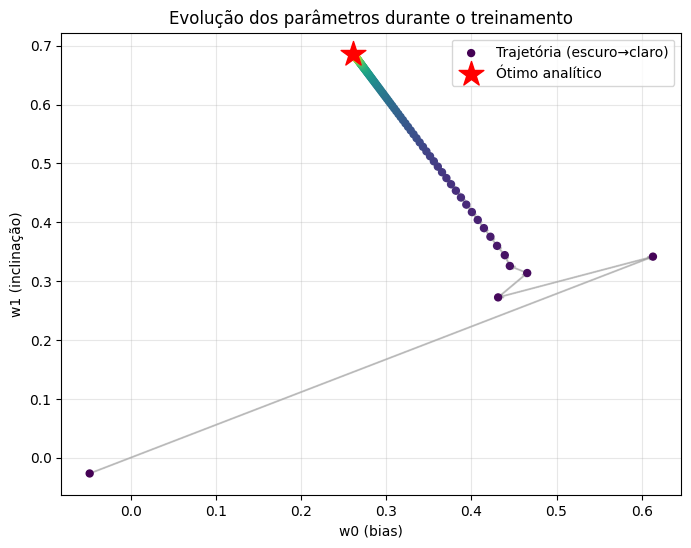

Parâmetros finais (GD): w0=0.2632, w1=0.6828
Parâmetros ótimos (analítico): w0=0.2613, w1=0.6865
Distância euclidiana ao ótimo: 0.00411


In [18]:
import numpy as np

# Recupera o ótimo analítico calculado anteriormente (w_opt)
w0_opt = w_opt[0, 0].item()
w1_opt = w_opt[1, 0].item()

plt.figure(figsize=(8, 6))

# trajetória colorida por época
plt.scatter(w0_list, w1_list, c=range(len(w0_list)),
            cmap='viridis', s=25, zorder=3, label='Trajetória (escuro→claro)')

# setas ligando passos consecutivos
w0_old = None
for (w0, w1) in zip(w0_list, w1_list):
    if w0_old is not None:
        plt.arrow(w0_old, w1_old, w0 - w0_old, w1 - w1_old,
                  head_length=0.006, head_width=0.006, shape='full',
                  length_includes_head=True, color='gray', alpha=0.4)
    w0_old, w1_old = w0, w1

# valor ótimo analítico
plt.scatter([w0_opt], [w1_opt], color='red', marker='*', s=350,
            zorder=5, label='Ótimo analítico')

plt.xlabel('w0 (bias)')
plt.ylabel('w1 (inclinação)')
plt.title('Evolução dos parâmetros durante o treinamento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# distância final ao ótimo
dist = np.sqrt((w0_list[-1]-w0_opt)**2 + (w1_list[-1]-w1_opt)**2)
print('Parâmetros finais (GD): w0={:.4f}, w1={:.4f}'.format(w0_list[-1], w1_list[-1]))
print('Parâmetros ótimos (analítico): w0={:.4f}, w1={:.4f}'.format(w0_opt, w1_opt))
print('Distância euclidiana ao ótimo: {:.5f}'.format(dist))

# Aprendizados

## Considerações finais

Este notebook introduz o uso efetivo do mecanismo de diferenciação automática (**autograd**) do PyTorch. Em comparação com as implementações anteriores (em NumPy e com tensores manipulados manualmente), a distinção fundamental reside na forma de obtenção do gradiente: em vez de derivá-lo analiticamente, basta invocar `loss.backward()`, e o PyTorch percorre o grafo computacional calculando $\partial \text{loss} / \partial w$ de modo automático. Três conceitos centrais foram consolidados:

1. **Distinção entre tensor e valor numérico (Atividade 1)**: um tensor com `requires_grad=True` mantém associado o grafo de operações. Para fins de impressão ou armazenamento do valor escalar, é necessário desacoplá-lo por meio de `.data`, `.item()` ou do contexto `torch.no_grad()`. A compreensão desse comportamento previne consumo excessivo de memória e erros relacionados ao cálculo de gradientes.

2. **Diferenciação entre avaliação e treinamento (Atividade 2)**: na medição do MSE final, a operação foi conduzida sob `torch.no_grad()`, pois não há necessidade de construir o grafo em uma etapa que não invoca `backward()`. O resultado obtido, **0,021170**, é consistente com os notebooks anteriores e com a solução analítica, confirmando que as três implementações convergem para o mesmo ponto.

3. **Convergência do otimizador (Atividade 3)**: a representação gráfica da trajetória de $(w_0, w_1)$ evidencia o comportamento do gradiente descendente, que parte da inicialização aleatória, executa passos de maior magnitude nas primeiras épocas — quando o gradiente é mais acentuado — e desacelera progressivamente até as proximidades do valor ótimo analítico. A distância final, da ordem de $10^{-3}$, não se anula em razão do número limitado de épocas, mas demonstra convergência consistente.

**Encaminhamento subsequente**: nesta implementação, a atualização dos pesos ainda é realizada de forma explícita (`model.weight.data = ... - lr * grad`). A etapa seguinte consiste em substituir esse procedimento por um otimizador dedicado, como `optim.SGD(model.parameters(), lr=...)`, utilizando os métodos `optimizer.step()` e `optimizer.zero_grad()`, de modo a delegar ao PyTorch também a etapa de atualização e completar o processo de automação iniciado com o `backward()`.